Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96595.png


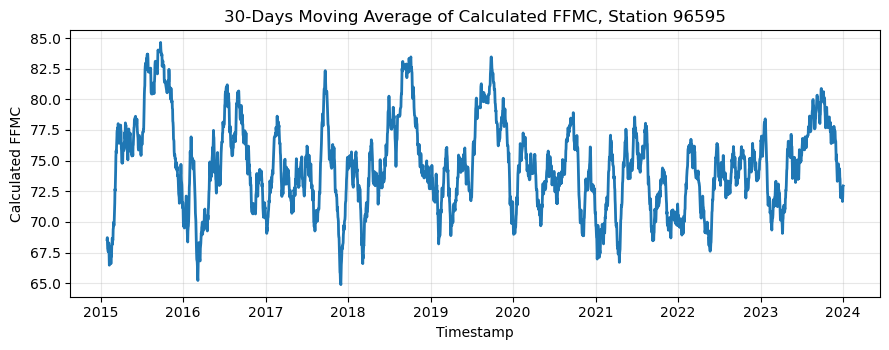

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96645.png


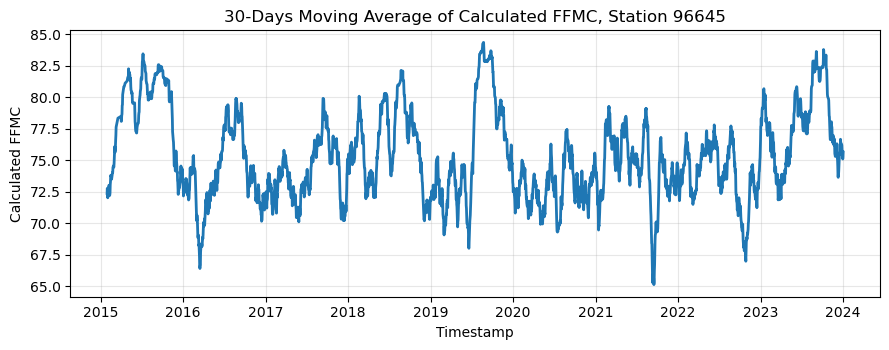

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96651.png


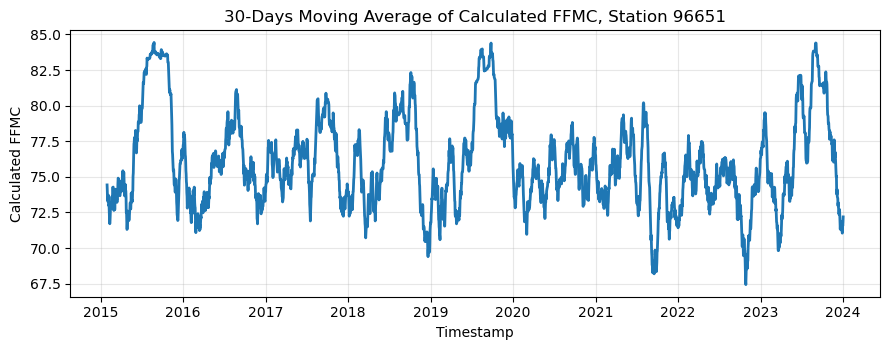

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96653.png


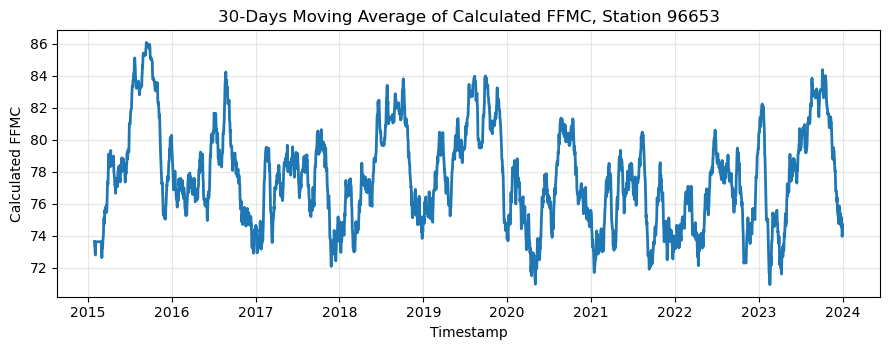

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96655.png


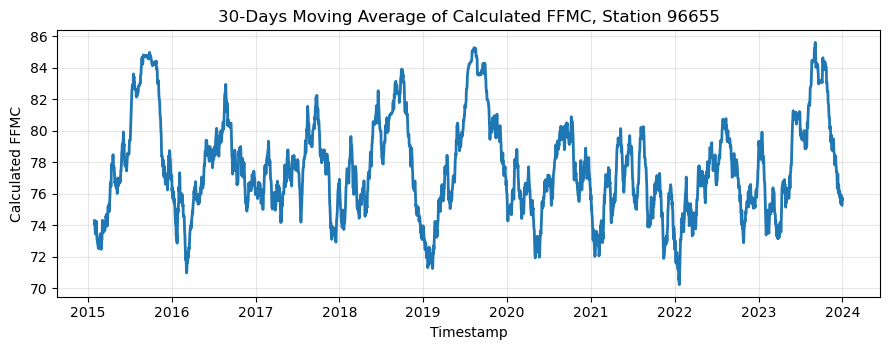

In [2]:
# === Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# === Path file (🔧 sesuaikan bila perlu)
CSV_PATH = Path("/home/rzby/ffmc_dc/data/processed/daily_features.csv")  # contoh lokasi
OUT_DIR   = Path("/home/rzby/ffmc_dc/reports/figures/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# === Baca Excel
df = pd.read_csv(CSV_PATH)

# --- Standarkan nama kolom agar mudah dideteksi
df.columns = [c.strip() for c in df.columns]

# === Deteksi kolom kunci (🔧 sesuaikan jika perlu)
# Tanggal: cari kolom yang mengandung 'date'
date_col = next((c for c in df.columns if "date" in c.lower()), None)
# Stasiun: cari 'station_id', 'wmo_id', 'wmo', atau 'station'
station_col = None
for key in ["station_id", "wmo_id", "wmo", "station"]:
    if station_col is None and any(key == c.lower() for c in df.columns):
        station_col = next(c for c in df.columns if c.lower() == key)
        break
# FFMC
ffmc_col = next((c for c in df.columns if c.lower() == "ffmc"), None)

assert date_col is not None,  "Kolom tanggal tidak ditemukan (cari yang mengandung 'date')."
assert station_col is not None,"Kolom stasiun tidak ditemukan (coba 'station_id'/'WMO'/'wmo_id')."
assert ffmc_col is not None,  "Kolom 'ffmc' tidak ditemukan."

# === Konversi tipe & sortir
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([station_col, date_col])

# === Hitung Moving Average 30 hari per stasiun
# Gunakan min_periods=30 agar MA-30 hanya terisi jika sudah ada 30 hari data
# (Jika ingin tidak ada NaN di awal deret, ganti min_periods=1)
df["ffmc_ma30"] = (
    df.groupby(station_col)[ffmc_col]
      .rolling(window=30, min_periods=30)
      .mean()
      .reset_index(level=0, drop=True)
)

# === Fungsi plot untuk satu stasiun
def plot_ma30_one_station(dfs, wmo_id, save_png=True):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(dfs[date_col], dfs["ffmc_ma30"], lw=2)

    # Sumbu waktu rapi
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Calculated FFMC")
    ax.set_title(f"30-Days Moving Average of Calculated FFMC, Station {wmo_id}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_png:
        out_path = OUT_DIR / f"ffmc_ma30_{wmo_id}.png"
        plt.savefig(out_path, dpi=300)
        print("Saved:", out_path)
    plt.show()

# === Loop semua stasiun dan plot
for sid, g in df.groupby(station_col):
    # Lewati jika semua nilai MA-30 NaN (mis. periode < 30 hari)
    if g["ffmc_ma30"].notna().any():
        plot_ma30_one_station(g, sid, save_png=True)
    else:
        print(f"Skip {sid}: belum cukup data untuk MA-30 (butuh ≥30 hari).")


Kolom Observed: ffmc
Kolom Prediksi: {'XGBoost': 'pred_xgb', 'ANN': 'pred_ann', 'SVM': 'pred_svm'}
Saved: reports/figures/scatter_xgboost.png


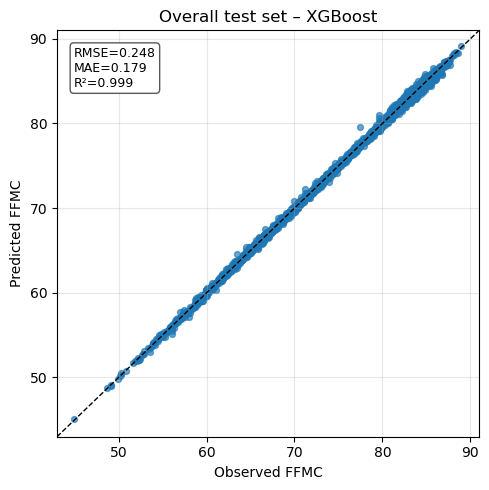

Saved: reports/figures/scatter_ann.png


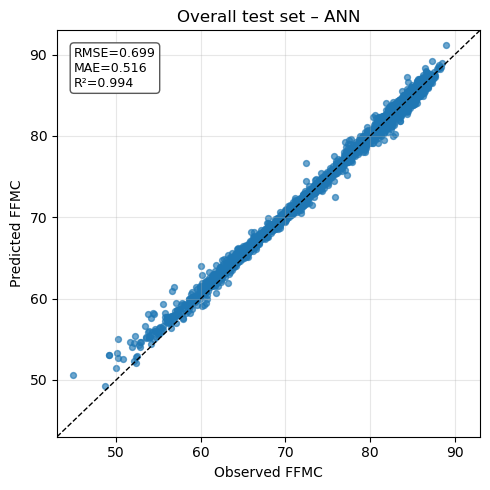

Saved: reports/figures/scatter_svm.png


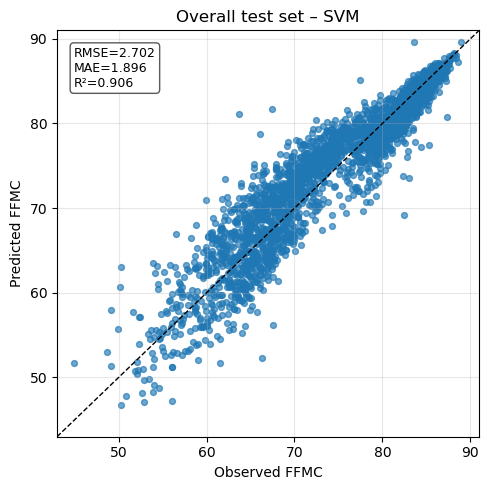

In [5]:
# === Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Path file (ubah jika perlu)
CSV_PATH = Path("/home/rzby/ffmc_dc/reports/output_table.csv")     # ganti sesuai lokasi file kamu
FIG_DIR  = Path("reports/figures/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Baca data
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

# === Deteksi kolom Observed (y_true)
CAND_YTRUE = ["ffmc", "observed", "obs", "y_true", "target"]
y_true_col = next((c for c in df.columns if c.lower() in CAND_YTRUE), None)
if y_true_col is None:
    # fallback: cari nama yang mengandung 'ffmc' + bukan prediksi
    candidates = [c for c in df.columns if "ffmc" in c.lower() and "pred" not in c.lower()]
    y_true_col = candidates[0] if candidates else None
assert y_true_col is not None, f"Tidak menemukan kolom Observed. Coba namai 'ffmc'/'observed'/'y_true'. Kolom saat ini: {df.columns.tolist()}"

# === Deteksi kolom Prediksi per model
def find_pred_col(df, key_list):
    # cari nama kolom yang mengandung salah satu kata kunci (case-insensitive)
    for c in df.columns:
        name = c.lower()
        if any(k in name for k in key_list) and ("pred" in name or "yhat" in name or "forecast" in name):
            return c
    # fallback: exact match umum
    exact = {
        "xgb": ["pred_xgb", "xgb_pred"],
        "ann": ["pred_ann", "ann_pred", "mlp_pred"],
        "svm": ["pred_svm", "svm_pred"]
    }
    for k in key_list:
        for e in exact.get(k, []):
            if e in df.columns:
                return e
    return None

pred_cols = {
    "XGBoost": find_pred_col(df, ["xgb", "xgboost"]),
    "ANN":     find_pred_col(df, ["ann", "mlp", "nn"]),
    "SVM":     find_pred_col(df, ["svm"])
}

# Hapus model yang kolom prediksinya tidak ditemukan
pred_cols = {m:c for m,c in pred_cols.items() if c is not None}
assert pred_cols, f"Tidak ada kolom prediksi yang ditemukan. Kolom saat ini: {df.columns.tolist()}"

print("Kolom Observed:", y_true_col)
print("Kolom Prediksi:", pred_cols)

# === Fungsi plot scatter untuk satu model
def plot_scatter_for_model(y_true, y_pred, model_name, out_png=None, annotate_metrics=True):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # Batas sumbu simetris mengacu pada min/max gabungan
    lo = np.floor(min(y_true.min(), y_pred.min()) - 1)
    hi = np.ceil (max(y_true.max(), y_pred.max()) + 1)

    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(y_true, y_pred, s=18, alpha=0.65)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)  # garis 1:1
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

    ax.set_xlabel("Observed FFMC")
    ax.set_ylabel("Predicted FFMC")
    ax.set_title(f"Overall test set – {model_name}")
    ax.grid(True, alpha=0.3)

    if annotate_metrics:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        text = f"RMSE={rmse:.3f}\nMAE={mae:.3f}\nR²={r2:.3f}"
        ax.text(0.04, 0.96, text, transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.35"), fontsize=9)

    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=300)
        print("Saved:", out_png)
    plt.show()

# === Buat plot untuk setiap model yang tersedia
for model_name, pred_col in pred_cols.items():
    out_path = FIG_DIR / f"scatter_{model_name.lower().replace(' ', '_')}.png"
    plot_scatter_for_model(df[y_true_col].to_numpy(),
                           df[pred_col].to_numpy(),
                           model_name,
                           out_png=out_path,
                           annotate_metrics=True)


In [24]:
# === Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import calendar

# === 🔧 Sesuaikan path & nama kolom bila perlu
INPUT_PATHS = [
    Path("/home/rzby/ffmc_dc/data/processed/daily_features.parquet"),  # prioritas
]
VALUE_COL = "qff_avg_hPa"        # kolom yang dianalisis IQR & diplot boxplot (ganti kalau perlu)

# --- cari file yang ada
for p in INPUT_PATHS:
    if p.exists():
        INP = p
        break
else:
    raise FileNotFoundError("File daily features tidak ditemukan. Periksa daftar 'INPUT_PATHS'.")

# === Baca data
if INP.suffix.lower() == ".parquet":
    df = pd.read_parquet(INP)
else:
    df = pd.read_excel(INP)

# --- Standarkan nama kolom agar mudah dideteksi
df.columns = [c.strip() for c in df.columns]

# --- Deteksi kolom tanggal & stasiun
date_col = next((c for c in df.columns if "date" in c.lower()), None)
station_col = None
for key in ["station_id", "wmo_id", "wmo", "station"]:
    if station_col is None and any(key == c.lower() for c in df.columns):
        station_col = next(c for c in df.columns if c.lower() == key)
        break

assert date_col is not None,  "Kolom tanggal tidak ditemukan (cari yang mengandung 'date')."
assert station_col is not None,"Kolom stasiun tidak ditemukan (coba 'station_id'/'WMO'/'wmo_id')."
assert VALUE_COL in df.columns, f"Kolom '{VALUE_COL}' tidak ada. Ubah VALUE_COL atau cek file."

# --- Tipe & turunan bulan
df[date_col] = pd.to_datetime(df[date_col])
df["month"] = df[date_col].dt.month

# --- Hanya nilai finite
df = df[np.isfinite(df[VALUE_COL])]
df.head()


,station_id,date_local,temp_13LT_C,rh_avg_pc,wind_avg_kmh,qff_avg_hPa,rain_mm,evap_mm,ffmc,month
0,96595,2015-01-01 00:00:00+00:00,32.2,71.39375,0.92600,1009.58750,3.0,4.0,73.688695,1
1,96595,2015-01-02 00:00:00+00:00,30.0,79.08750,0.92600,1010.58125,0.0,3.0,83.174782,1
2,96595,2015-01-03 00:00:00+00:00,31.1,79.30000,0.00000,1010.85625,0.0,3.0,84.831423,1
3,96595,2015-01-04 00:00:00+00:00,30.9,76.87500,1.15750,1009.85000,20.5,6.0,60.330249,1
4,96595,2015-01-05 00:00:00+00:00,29.2,85.48750,0.57875,1010.38750,10.8,6.0,58.220215,1


In [28]:
df.groupby('station_id').describe().to_excel('/home/rzby/ffmc_dc/notebooks/reports/outliers/full_data_desc.xlsx')

In [25]:
# === 1) Deteksi outlier IQR per (stasiun, bulan) — lintas tahun
def calc_iqr_flags(g: pd.DataFrame, col: str):
    # hitung Q1, Q3, IQR pada grup
    q1 = g[col].quantile(0.25)
    q3 = g[col].quantile(0.75)
    iqr = q3 - q1
    k = 1.5  # Tukey fences
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    flags = (g[col] < lo) | (g[col] > hi)
    out = g.copy()
    out[f"{col}_outlier"] = flags
    out[f"{col}_q1"] = q1
    out[f"{col}_q3"] = q3
    out[f"{col}_iqr"] = iqr
    out[f"{col}_lo"] = lo
    out[f"{col}_hi"] = hi
    return out

flagged = (
    df.groupby([station_col, "month"], group_keys=False)
      .apply(lambda g: calc_iqr_flags(g, VALUE_COL))
      .sort_values([station_col, "month", date_col])
)

# === Ringkasan outlier per (stasiun, bulan)
summary = (
    flagged.groupby([station_col, "month"])
           .apply(lambda g: pd.Series({
               "n": int(g.shape[0]),
               "n_outlier": int(g[f"{VALUE_COL}_outlier"].sum()),
               "pct_outlier": float(100 * g[f"{VALUE_COL}_outlier"].mean()),
               "q1": float(g[f"{VALUE_COL}_q1"].iloc[0]),
               "q3": float(g[f"{VALUE_COL}_q3"].iloc[0]),
               "lo": float(g[f"{VALUE_COL}_lo"].iloc[0]),
               "hi": float(g[f"{VALUE_COL}_hi"].iloc[0]),
           }))
           .reset_index()
)
summary.head()


/tmp/ipykernel_4320/4226494925.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: calc_iqr_flags(g, VALUE_COL))
/tmp/ipykernel_4320/4226494925.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,station_id,month,n,n_outlier,pct_outlier,q1,q3,lo,hi
0,96595,1,281.0,3.0,1.067616,1008.893750,1011.093750,1005.593750,1014.393750
1,96595,2,254.0,0.0,0.000000,1009.491667,1011.799479,1006.029948,1015.261198
2,96595,3,279.0,1.0,0.358423,1009.454167,1011.564583,1006.288542,1014.730208
3,96595,4,270.0,2.0,0.740741,1009.276042,1010.951042,1006.763542,1013.463542
4,96595,5,279.0,0.0,0.000000,1009.002083,1011.031250,1005.958333,1014.075000


In [26]:
# === Simpan hasil
OUT_DIR = Path("/home/rzby/ffmc_dc/notebooks/reports/outliers")
FIG_DIR = Path("/home/rzby/ffmc_dc/notebooks/reports/figures/boxplots")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

flagged.to_csv(OUT_DIR / f"outliers_iqr_rows_{VALUE_COL}.csv", index=False)
summary.to_csv(OUT_DIR / f"outliers_iqr_summary_{VALUE_COL}.csv", index=False)
print("Saved:", OUT_DIR / f"outliers_iqr_rows_{VALUE_COL}.csv")
print("Saved:", OUT_DIR / f"outliers_iqr_summary_{VALUE_COL}.csv")


Saved: /home/rzby/ffmc_dc/notebooks/reports/outliers/outliers_iqr_rows_qff_avg_hPa.csv
Saved: /home/rzby/ffmc_dc/notebooks/reports/outliers/outliers_iqr_summary_qff_avg_hPa.csv


Saved: /home/rzby/ffmc_dc/notebooks/reports/figures/boxplots/boxplot_qff_avg_hPa_96595.png


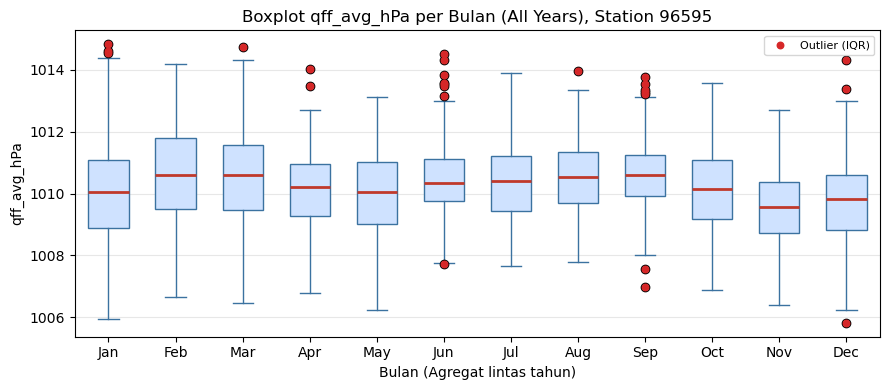

Saved: /home/rzby/ffmc_dc/notebooks/reports/figures/boxplots/boxplot_qff_avg_hPa_96645.png


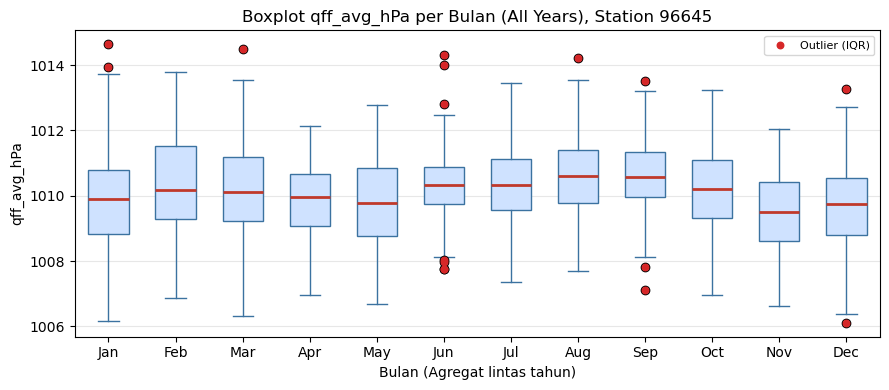

Saved: /home/rzby/ffmc_dc/notebooks/reports/figures/boxplots/boxplot_qff_avg_hPa_96651.png


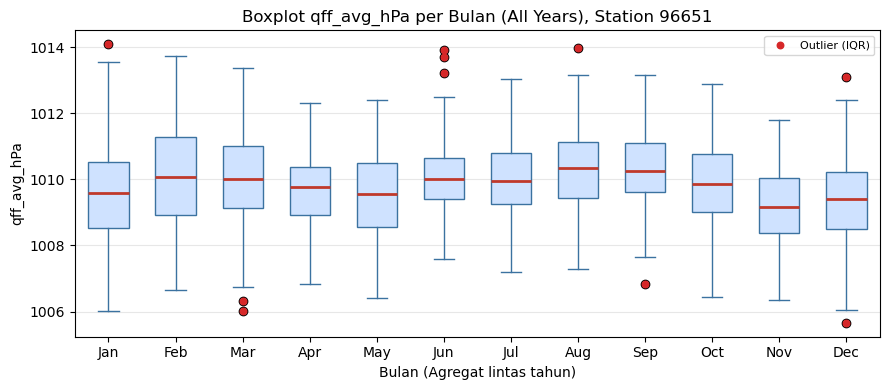

Saved: /home/rzby/ffmc_dc/notebooks/reports/figures/boxplots/boxplot_qff_avg_hPa_96653.png


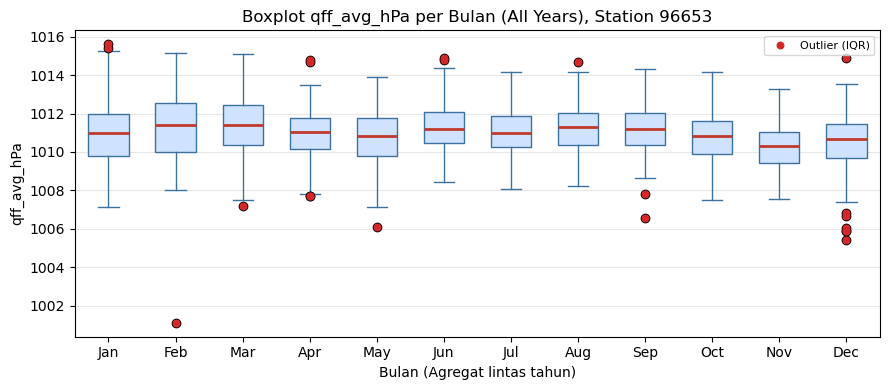

Saved: /home/rzby/ffmc_dc/notebooks/reports/figures/boxplots/boxplot_qff_avg_hPa_96655.png


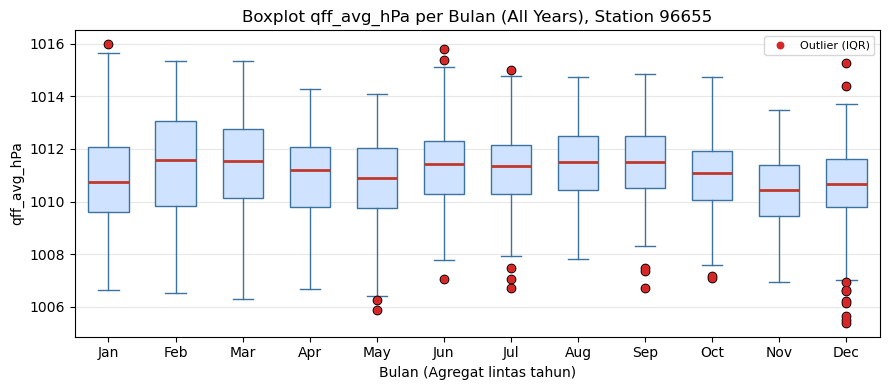

In [27]:
# === 2) Boxplot per stasiun (1 gambar/stasiun), agregat per bulan lintas tahun
#     - Boxplot mengikuti definisi Tukey (IQR), selaras dengan deteksi outlier di atas
#     - Titik outlier dari perhitungan kita dioverlay sebagai marker merah

def month_labels():
    # Label Jan..Dec
    return [calendar.month_abbr[m] for m in range(1, 13)]

def plot_boxplot_station(g: pd.DataFrame, station_id, VALUE_COL=VALUE_COL, save=True):
    # Susun data per bulan (Jan..Dec)
    data_by_month = [g.loc[g["month"] == m, VALUE_COL].values for m in range(1, 13)]

    fig, ax = plt.subplots(figsize=(9, 4))
    bp = ax.boxplot(
        data_by_month,
        positions=range(1, 13),
        widths=0.6,
        patch_artist=True,
        showfliers=True  # biarkan outlier Tukey standar ditampilkan
    )

    # Warna lembut
    for patch in bp["boxes"]:
        patch.set_facecolor("#cfe2ff")
        patch.set_edgecolor("#3b72a0")
    for whisker in bp["whiskers"]:
        whisker.set_color("#3b72a0")
    for cap in bp["caps"]:
        cap.set_color("#3b72a0")
    for median in bp["medians"]:
        median.set_color("#c0392b")
        median.set_linewidth(2)

    # Overlay titik outlier hasil flag IQR kita (lebih jelas)
    gg = g.copy()
    gg_out = gg[gg[f"{VALUE_COL}_outlier"]]
    # x-position = bulan
    ax.scatter(
        gg_out["month"],
        gg_out[VALUE_COL],
        color="#d62728", s=22, zorder=3, label="Outlier (IQR)"
    )

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels())
    ax.set_xlabel("Bulan (Agregat lintas tahun)")
    ax.set_ylabel(f"{VALUE_COL}")
    ax.set_title(f"30-Days Moving Average of Calculated FFMC, Station {station_id}" if VALUE_COL.lower()=="ffmc"
                 else f"Boxplot {VALUE_COL} per Bulan (All Years), Station {station_id}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()

    if save:
        out_png = FIG_DIR / f"boxplot_{VALUE_COL}_{station_id}.png"
        plt.savefig(out_png, dpi=300)
        print("Saved:", out_png)
    plt.show()

# --- Pastikan flagged (dengan kolom *_outlier) digunakan
for sid, g in flagged.groupby(station_col):
    if g[VALUE_COL].notna().sum() >= 10:  # syarat minimal
        plot_boxplot_station(g, sid, VALUE_COL=VALUE_COL, save=True)
    else:
        print(f"Skip {sid}: data terlalu sedikit untuk boxplot.")
